# Pipeline stage 3: characterization of phage-encoded acetyltransferase Map

### Stage 3.3: *in vivo* impact of Map expression (metabolome visualization)

In our research, we have characterized LUZ19 gp13/Map. To assess its impact on host physiology, we have compared the metabolome of Map expressing versus control *P. aeruginosa* PAO1 strains. In this notebook, we will parse and visualize these results, to help interpreting them.

**Goals:**
* Parse metabolome data.
* Visualize metabolome data.

**Requires:**
* Metabolome data files S3_intensities.tsv and S3_changes.tsv, stored in data/: tab-separated files containing the metabolomics data (corrrespond to the two sheets of supplementary table S3 of the manuscript)

**Generates:**
* 5-Methylthioadenosine_metabolome.svg and S-Adenosyl-L-homocysteine_metabolome.svg : dotplots visualizing normalized metabolite intensities of Map expressing and control *P. aeruginosa* PAO1 cells as measured during a 120-minute timecourse untargeted metabolomics experiment. 

#### General settings, imports, variables and environments

Conda environment: viral_act_map_invivo

Created with `conda create -n viral_act_map_invivo python=3.10`. Then installed  `jupyter notebook`, `pandas` through conda (command `conda install`), and `seaborn` through pip (command below).

In [ ]:
!pip install seaborn

In [1]:
!conda list --explicit

# This file may be used to create an environment using:
# $ conda create --name <env> --file <this file>
# platform: win-64
# created-by: conda 24.11.3
@EXPLICIT
https://conda.anaconda.org/conda-forge/noarch/ca-certificates-2026.1.4-h4c7d964_0.conda
https://conda.anaconda.org/conda-forge/noarch/python_abi-3.10-8_cp310.conda
https://conda.anaconda.org/conda-forge/noarch/tzdata-2025c-hc9c84f9_1.conda
https://conda.anaconda.org/conda-forge/win-64/ucrt-10.0.26100.0-h57928b3_0.conda
https://conda.anaconda.org/conda-forge/win-64/winpty-0.4.3-4.tar.bz2
https://conda.anaconda.org/conda-forge/win-64/libwinpthread-12.0.0.r4.gg4f2fc60ca-h57928b3_10.conda
https://conda.anaconda.org/conda-forge/win-64/vcomp14-14.44.35208-h818238b_34.conda
https://conda.anaconda.org/conda-forge/win-64/vc14_runtime-14.44.35208-h818238b_34.conda
https://conda.anaconda.org/conda-forge/win-64/vc-14.3-h41ae7f8_34.conda
https://conda.anaconda.org/conda-forge/win-64/bzip2-1.0.8-h0ad9c76_9.conda
https://conda.anaconda.org/c

In [2]:
# imports 
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# clear reference to different directories
pipeline_map_dir = os.getcwd()
master_dir = os.path.abspath(os.path.join(pipeline_map_dir, os.pardir, os.pardir))

In [ ]:
# creating a directory for all the data we will generate
os.mkdir(os.path.join(pipeline_map_dir, "c_invivo_analysis"))

#### Goal 1 : parse metabolome data

Let's first read in the different tables containing all the metabolome data.

In [4]:
# reading in the data as is
metabo_int = pd.read_csv(os.path.join(pipeline_map_dir, "c_invivo_analysis", "data", "S3_intensities.tsv"), sep = "\t", decimal = ",")
metabo_delta = pd.read_csv(os.path.join(pipeline_map_dir, "c_invivo_analysis", "data", "S3_changes.tsv"), sep = "\t", decimal = ",")

In [5]:
# merging the data on the shared columns
metabo_merged = pd.merge(metabo_int, metabo_delta)

Let's have a look at which metabolites changed consistently (and significantly) after Map expression.

In [6]:
# let's first have a look at those that changed siginificantly post-induction
adj_p_col = metabo_merged.filter(like = "adjusted p-value")
adj_p_col_pi = adj_p_col.loc[:, ~adj_p_col.columns.str.contains("t=0")]
    # significanly changed in all post-induction timepoints
mask_allpisig = (adj_p_col_pi < 0.05).all(axis=1)
metabo_allpisig = metabo_merged[mask_allpisig]
    # significantly changed in at least one post-induction timepoint
mask_1pisig = (adj_p_col_pi < 0.05).any(axis=1)
metabo_1pisig = metabo_merged[mask_1pisig]


In [7]:
metabo_allpisig

,ion m/z,ion identifier,ion names,KEGG pathways,m/z delta,formula,normalized intensity control at t=0 (replicate A),normalized intensity control at t=0 (replicate B),normalized intensity control at t=0 (replicate C),normalized intensity control at t=0 (replicate D),...,adjusted p-value log2 fold change at t=45,log2 fold change at t=60,p-value log2 fold change at t=60,adjusted p-value log2 fold change at t=60,log2 fold change at t=90,p-value log2 fold change at t=90,adjusted p-value log2 fold change at t=90,log2 fold change at t=120,p-value log2 fold change at t=120,adjusted p-value log2 fold change at t=120
184,243.030178,C01099;,L-Fuculose 1-phosphate;,Fructose and mannose metabolism;,"-0,0026543;",C6H13O8P;,18143.239,17945.935,21175.657,20639.570,...,0.003,-0.828,0.001,0.019,-0.871,0.0,0.002,-0.867,0.0,0.028
245,383.112680,C00021;,S-Adenosyl-L-homocysteine;,Cysteine and methionine metabolism;,"0,0016281;",C14H20N6O5S;,24943.198,23548.513,30708.154,23036.673,...,0.012,-1.482,0.000,0.011,-1.776,0.0,0.001,-1.960,0.0,0.028
252,402.082735,C05983;,Propionyladenylate;Propionyl-adenosine monopho...,Propanoate metabolism;,"-0,00071718;",C13H18N5O8P;,8142.539,8961.017,7505.789,10101.574,...,0.002,-1.291,0.000,0.001,-1.585,0.0,0.004,-1.639,0.0,0.001


Only three metabolites have changed significantly across all post-induction timepoints: L-fucolose 1-phosphate, propionyladenylate/propionyl-adenosine monophosphate and S-adesonyl-L-homocysteine. Interestingly, the latter one does belong to the 'cysteine and methionine metabolism', just like MetE and MetK do.

Let's also have a look at those with the largest significant changes following induction (does not have to be significant across all timepoints):

In [8]:
# extract fold change
fc_col = metabo_merged.filter(like = "log2 fold change at t=")
fc_col_pi = fc_col.loc[:, ~fc_col.columns.str.contains("t=0")]
# convert to long format for easier plotting and filtering
fc_long = (fc_col_pi.reset_index().melt(id_vars = "index", var_name = "fc_col_pi", value_name = "log2FC"))
p_long = (adj_p_col_pi.reset_index().melt(id_vars = "index", var_name = "adj_p_col_pi", value_name = "adj_p"))
# extract time from column names
fc_long["time"] = fc_long["fc_col_pi"].str.extract(r"(t=\d+)")
p_long["time"] = p_long["adj_p_col_pi"].str.extract(r"(t=\d+)")
# merge fold change and p-value dataframes on index and time
merged_long = fc_long.merge(p_long[["index", "time", "adj_p"]], on = ["index", "time"])
# keep only significant changes
merged_long = merged_long[merged_long["adj_p"] < 0.05]
# rank by fold change
merged_long["abs_log2FC"] = merged_long["log2FC"].abs()
merged_long = merged_long.sort_values("abs_log2FC", ascending = False)
# link back to metabolite annotations
annotation_cols = ["ion m/z", "ion identifier", "ion names", "KEGG pathways", "m/z delta", "formula"]
annotation_cols = [c for c in annotation_cols if c in metabo_merged.columns]
merged_long = merged_long.merge(metabo_merged[annotation_cols], left_on = "index", right_index = True, how = "left")
# reorder for readability
cols_order = (annotation_cols + ["time", "log2FC", "abs_log2FC", "adj_p"])
cols_order = [c for c in cols_order if c in merged_long.columns]
merged_long = merged_long[cols_order]
# extract top 10 most changed metabolites
top10 = (merged_long.drop_duplicates(subset="ion identifier", keep="first").head(10))


In [9]:
# let's see how often those ions appeared when we were getting to the top 10, 
# to have an idea of how many time points they were significant in and how high they ranked in those time points. 

# intantiating necessary variables
counts = {}
unique_ions = []
rows_processed = 0

# looping over the dataframe until we have seen 10 unique ions, counting how many times we see each ion until then
for idx, ion in enumerate(merged_long["ion identifier"]):
    rows_processed += 1
    if ion not in unique_ions:
        unique_ions.append(ion)
        counts[ion] = 1
    else:
        counts[ion] += 1
    if len(unique_ions) == 10:
        break

# take the subset of merged_long corresponding to those rows
top_n_rows = merged_long.iloc[:rows_processed].copy()

# add a column with counts per ion
top_n_rows["count_until_topN"] = top_n_rows["ion identifier"].map(counts)

# create top 10 table by keeping only the first occurrence per ion
top10 = (top_n_rows.drop_duplicates(subset="ion identifier", keep="first"))
top10 = top10[["ion names", "KEGG pathways", "log2FC", "count_until_topN"]]
top10

,ion names,KEGG pathways,log2FC,count_until_topN
4276,"5-Hydroxyindoleacetate;5-Phenyl-1,3-oxazinane-...",Tryptophan metabolism;,5.528,5
4356,5-Methylthioadenosine;,Cysteine and methionine metabolism;,4.681,5
3286,"6,7-Dihydrobiopterin;",Folate biosynthesis;,4.632,2
2228,2-C-methyl-D-erythritol 4-phosphate;,Terpenoid backbone biosynthesis;,-4.346,3
4184,4-Hydroxy-L-threonine;,Vitamin B6 metabolism;,4.136,5
2193,2-Deoxy-D-gluconate;D-Glucose;D-Fructose;Levul...,Glycolysis / Gluconeogenesis; Pentose phosphat...,-3.217,1
2257,N2-Succinyl-L-glutamate;,Arginine and proline metabolism;,-3.176,3
2371,Nicotinamide adenine dinucleotide - reduced;,Oxidative phosphorylation;,2.944,1
5486,Propanoyl-CoA;,"Valine, leucine and isoleucine degradation; be...",2.739,1
4193,"(1R,2S)-Naphthalene(1R,2S)-Naphthalene epoxide...",NaN,2.389,1


Interestingly, across the 10 metabolites with the largest significant changes, we again see one belonging to the cysteine and methionine metabolism: 5-methylthioadenosine (with 5 out of 6 post-induction time points included). No other pathway overlaps with the previous table. 

#### Goal 2 : visualize metabolome data

Now that we have observed which metabolites change consistently and/or in a major fashion, let's visualize the results. We will specifically focus on visualizing the metabolites related to MetE/MetK, but the plotting code can be used to run any metabolite of interest.

In [ ]:
# function to generate plots for metabolite
def plot_metabolite_timecourse_from_columns(df, metabolite_name):
    # filter for metabolite
    df_met = df[df["ion names"] == metabolite_name].iloc[0]
    # dictionaries to store the two conditions, and the significance of the difference
    control_data = {}
    exp_data = {}
    pvals = {}

    # parse input data
    for col in df.columns:
        if "t=" in col:
            # extract timepoint from column name
            t = float(re.search(r"t=([0-9\.]+)", col).group(1))
            # extract values for the two conditions, and p-values
            if "control" in col:
                control_data.setdefault(t, []).append(df_met[col])
            if "Map" in col:
                exp_data.setdefault(t, []).append(df_met[col])
            if "adjusted p-value" in col:
                pvals[t] = df_met[col]

    # sort timepoints into categorical x-axis labels
    timepoints = sorted(control_data.keys())
    categories = [str(int(t)) for t in timepoints]
    x = np.arange(len(categories))

    # start plotting
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(4, 3))
    # go over time points
    for i, t in enumerate(timepoints):
        # control points
        c_vals = np.array(control_data[t], dtype=float)
        ax.scatter(
            np.full_like(c_vals, x[i]) - 0.08,  # slight offset for better visibility,
            c_vals,
            facecolors = "white",
            edgecolors = "#202020", 
            alpha = 0.9,
            s = 40,
            linewidth = 0.8,
        )
        # Map points
        e_vals = np.array(exp_data[t], dtype=float)
        ax.scatter(
            np.full_like(e_vals, x[i]) + 0.08,  # slight offset for better visibility
            e_vals,
            color = "#202020",
            alpha = 0.9,
            s = 40,
            edgecolor = "#202020",
            linewidth = 0.8,
        )
    # adding in ticks
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    # adding in labels
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Normalized intensity")
    sns.despine()
    fig.tight_layout()
    # show plot
    fig.show()
    # print p-values for each time point
    print(f"P-values for {metabolite_name}:")
    for t in timepoints:
        print(f"Time {t} min: p-value = {pvals[t]:.4f}")
    # to save the plot without labels, uncomment this
    # ax.set_xlabel("")
    # ax.set_ylabel("")
    # ax.tick_params(labelbottom = False, labelleft = False)
    # pretty_metabolite_name = metabolite_name.replace(" ", "_").replace(";", "")
    # fig.savefig(os.path.join(pipeline_map_dir, "c_invivo_analysis", f"{pretty_metabolite_name}_metabolome.svg"), format = "svg", transparent = True)


C:\Users\hanne\AppData\Local\Temp\ipykernel_22764\3748549007.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\hanne\AppData\Local\Temp\ipykernel_22764\3748549007.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


P-values for S-Adenosyl-L-homocysteine;:
Time 0.0 min: p-value = 0.0310
Time 15.0 min: p-value = 0.0150
Time 30.0 min: p-value = 0.0300
Time 45.0 min: p-value = 0.0120
Time 60.0 min: p-value = 0.0110
Time 90.0 min: p-value = 0.0010
Time 120.0 min: p-value = 0.0280
P-values for 5-Methylthioadenosine;:
Time 0.0 min: p-value = 0.0100
Time 15.0 min: p-value = 0.0050
Time 30.0 min: p-value = 0.0030
Time 45.0 min: p-value = 0.0070
Time 60.0 min: p-value = 0.0020
Time 90.0 min: p-value = 0.0010
Time 120.0 min: p-value = 0.1960


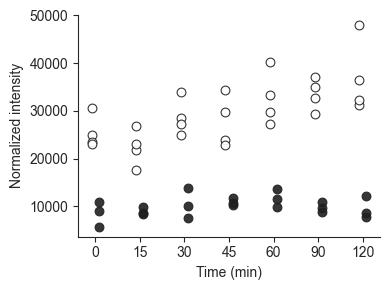

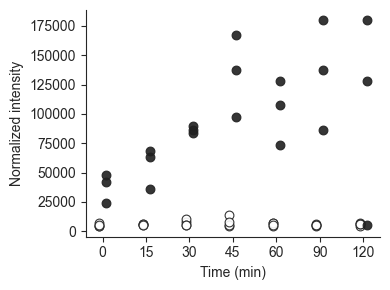

In [11]:
plot_metabolite_timecourse_from_columns(metabo_merged, "S-Adenosyl-L-homocysteine;")
plot_metabolite_timecourse_from_columns(metabo_merged, "5-Methylthioadenosine;")